# Zero-Noise Extrapolation — pushing past the gate-error ceiling

Parity-QREM mitigates **readout** error after the fact. But CZ **gate errors** during preparation are the dominant noise source for our circuits, and QREM does nothing for them.

**ZNE idea**: run the same logical circuit at multiple gate-noise levels α (1×, 3×, 5×), measure W(α), then fit and **extrapolate to α = 0** (zero-noise limit).

**How we scale noise**: CZ gate folding. CZ² = I, so replacing each CZ with three CZs in a row is logically equivalent but accumulates 3× the noise. Five CZs gives 5× the noise. Same logical circuit, more gate errors.

Reference: Temme, Bravyi, Gambetta — *Error mitigation for short-depth quantum circuits*, **PRL 119, 180509 (2017)**.

In [1]:
import sys, time
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import get_backend, is_simulator, select_best_tree, get_qubit_metrics
from src.circuits.graph_state import build_graph_state, neighbours_from_edges
from src.witnesses.gme_graph import build_gme_circuits_graph, compute_gme_witness_graph, gme_significance_graph
from src.mitigation.parity_qrem import correction_factors_from_metrics
from src.mitigation.zne import fold_cz_gates, extrapolate_to_zero_noise

TARGET_N = 20
SCALES = [1, 3, 5]
SHOTS = 1500

backend = get_backend(device='emerald')
qm, _ = get_qubit_metrics(backend)
correction_factors = correction_factors_from_metrics(qm)
print(f'Backend: {backend} (hardware: {not is_simulator(backend)})')
print(f'Target n: {TARGET_N},  noise scales: {SCALES},  shots/circuit: {SHOTS}')

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x00000281502F2F00> (hardware: True)
Target n: 20,  noise scales: [1, 3, 5],  shots/circuit: 1500


In [2]:
tree = select_best_tree(backend, TARGET_N)
qubits = tree['qubits']
log_edges = tree['logical_edges']
coloring = tree['coloring']
print(f'Tree cost: {tree["weight"]:.4f}  predicted W: {tree["predicted_W"]:.3f} / {TARGET_N}')
print(f'Qubits: {qubits}')

Tree cost: 0.3982  predicted W: 18.750 / 20
Qubits: [16, 17, 22, 23, 24, 25, 26, 32, 33, 34, 35, 36, 41, 44, 46, 47, 48, 51, 52, 53]


## Build folded circuits at scales 1, 3, 5

All scales correspond to the **same** logical state preparation (since CZ² = I).
Only the gate-error budget changes.

In [3]:
state = build_graph_state(TARGET_N, log_edges)
circ_a, circ_b = build_gme_circuits_graph(state, coloring)
all_circuits = []
for s in SCALES:
    fa = fold_cz_gates(circ_a, s)
    fb = fold_cz_gates(circ_b, s)
    transpiled = transpile([fa, fb], backend=backend,
                            initial_layout=qubits, optimization_level=3)
    all_circuits.extend(transpiled)
    n_cz = transpiled[0].count_ops().get('cz', 0)
    print(f'scale {s}: {n_cz} CZ gates per circuit, depth {transpiled[0].depth()}')

scale 1: 19 CZ gates per circuit, depth 15
scale 3: 57 CZ gates per circuit, depth 39
scale 5: 95 CZ gates per circuit, depth 63


## Submit one job (6 circuits) — each scale shares the same calibration window

In [4]:
t0 = time.time()
job = backend.run(all_circuits, shots=SHOTS)
try: print(f'Job ID: {job.job_id()}')
except Exception: pass
counts = job.result().get_counts()
print(f'Done in {time.time()-t0:.1f}s')
print(f'Got {len(counts)} count dicts')

Job ID: 019e0de4-61a6-7b61-99ae-149ce73224b6


Done in 8.5s
Got 6 count dicts


In [5]:
results = []
for i, scale in enumerate(SCALES):
    cA = counts[2*i]; cB = counts[2*i+1]
    res = compute_gme_witness_graph(cA, cB, TARGET_N, log_edges, coloring)
    sigma_raw = gme_significance_graph(res['W'], TARGET_N, SHOTS)

    # Apply parity QREM at each scale
    nbrs = neighbours_from_edges(TARGET_N, log_edges)
    stab_mit = {}
    for q in range(TARGET_N):
        involved = [q] + nbrs[q]
        factor = 1.0
        for lq in involved:
            factor *= correction_factors.get(qubits[lq], 1.0)
        stab_mit[q] = res['stabilizer_values'][q] * factor
    W_mit = sum(stab_mit.values())
    sigma_mit = gme_significance_graph(W_mit, TARGET_N, SHOTS)

    results.append({
        'scale': scale, 'W_raw': res['W'], 'W_mit': W_mit,
        'sigma_raw': sigma_raw, 'sigma_mit': sigma_mit,
        'g_raw_mean': float(np.mean(list(res['stabilizer_values'].values()))),
        'g_mit_mean': float(np.mean(list(stab_mit.values()))),
    })
    print(f'scale={scale}:  raw W={res["W"]:7.3f} (σ={sigma_raw:+6.2f}, ⟨g⟩={results[-1]["g_raw_mean"]:.3f})  '
          f'+QREM W={W_mit:7.3f} (σ={sigma_mit:+6.2f}, ⟨g⟩={results[-1]["g_mit_mean"]:.3f})')

scale=1:  raw W= 15.485 (σ=-30.44, ⟨g⟩=0.774)  +QREM W= 17.522 (σ=-12.80, ⟨g⟩=0.876)
scale=3:  raw W= 12.760 (σ=-54.04, ⟨g⟩=0.638)  +QREM W= 14.296 (σ=-40.73, ⟨g⟩=0.715)
scale=5:  raw W=  9.356 (σ=-83.52, ⟨g⟩=0.468)  +QREM W= 10.367 (σ=-74.76, ⟨g⟩=0.518)


## Extrapolate to zero noise

Three fitting methods:
- **Linear**: simplest, robust to outliers, may underestimate W(0)
- **Quadratic**: captures curvature, needs 3 points
- **Exponential**: assumes W(α) = A·exp(−γα), often the best physical match

In [6]:
scales_arr = [r['scale'] for r in results]
W_raw_arr = [r['W_raw'] for r in results]
W_mit_arr = [r['W_mit'] for r in results]

# Apply ZNE separately to raw and to mitigated values
ext_raw = {}
ext_mit = {}
for method in ['linear', 'quadratic', 'exponential']:
    try:
        ext_raw[method] = extrapolate_to_zero_noise(scales_arr, W_raw_arr, method)[0]
        ext_mit[method] = extrapolate_to_zero_noise(scales_arr, W_mit_arr, method)[0]
    except Exception as e:
        print(f'  {method}: {e}')

bound = TARGET_N - 1
print(f'Bound for GME: W > {bound}')
print(f'Ideal:         W = {TARGET_N}')
print()
print(f'{"method":15} {"W extrapolated (raw)":>22} {"W extrapolated (+QREM)":>24}')
for method in ['linear', 'quadratic', 'exponential']:
    r = ext_raw.get(method, np.nan)
    m = ext_mit.get(method, np.nan)
    rcheck = '✓' if r > bound else '✗'
    mcheck = '✓' if m > bound else '✗'
    print(f'{method:15} {r:>20.3f} {rcheck}    {m:>20.3f} {mcheck}')

Bound for GME: W > 19
Ideal:         W = 20

method            W extrapolated (raw)   W extrapolated (+QREM)
linear                        17.131 ✗                  19.427 ✓
quadratic                     16.594 ✗                  18.870 ✗
exponential                   17.909 ✗                  20.374 ✓


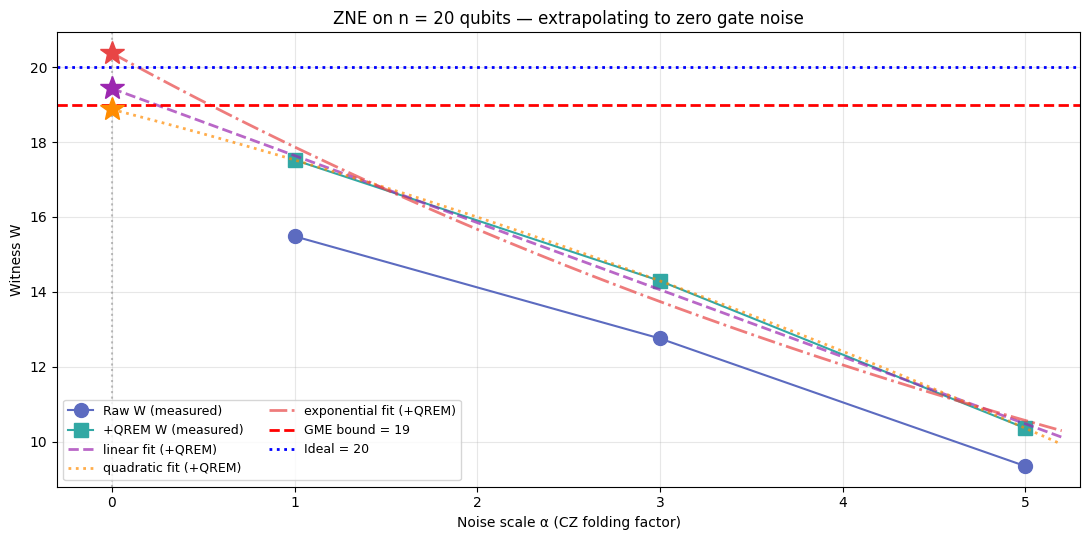

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(scales_arr, W_raw_arr, 'o-', color='#5c6bc0', markersize=10, label='Raw W (measured)')
ax.plot(scales_arr, W_mit_arr, 's-', color='#32a8a4', markersize=10, label='+QREM W (measured)')

# Smooth fit curves
alpha_dense = np.linspace(0, max(scales_arr) + 0.2, 100)
for method, color, ls in [('linear', '#9c27b0', '--'),
                           ('quadratic', '#ff8b00', ':'),
                           ('exponential', '#e84545', '-.')]:
    try:
        _, info = extrapolate_to_zero_noise(scales_arr, W_mit_arr, method)
        if method == 'linear':
            y = info['a'] + info['b'] * alpha_dense
        elif method == 'quadratic':
            y = info['a'] + info['b'] * alpha_dense + info['c'] * alpha_dense**2
        else:
            y = info['A'] * np.exp(-info['gamma'] * alpha_dense)
        ax.plot(alpha_dense, y, ls, color=color, linewidth=2, alpha=0.7,
                label=f'{method} fit (+QREM)')
        ax.plot(0, ext_mit[method], '*', color=color, markersize=18, zorder=10)
    except Exception:
        pass

ax.axhline(bound, color='red', linestyle='--', linewidth=2, label=f'GME bound = {bound}')
ax.axhline(TARGET_N, color='blue', linestyle=':', linewidth=2, label=f'Ideal = {TARGET_N}')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Noise scale α (CZ folding factor)')
ax.set_ylabel('Witness W')
ax.set_title(f'ZNE on n = {TARGET_N} qubits — extrapolating to zero gate noise')
ax.legend(loc='lower left', fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.3, max(scales_arr) + 0.3)
plt.tight_layout()
plt.savefig(f'zne_n{TARGET_N}.png', dpi=130, bbox_inches='tight')
plt.show()

In [8]:
print('=' * 60)
print(f'SUMMARY — n = {TARGET_N} qubits')
print('=' * 60)
best_mit_method = max(ext_mit.keys(), key=lambda k: ext_mit[k])
best_W_mit = ext_mit[best_mit_method]
best_sigma = (best_W_mit - bound) / (np.sqrt(TARGET_N) / np.sqrt(SHOTS))
print(f'  Raw W at scale=1            : {results[0]["W_raw"]:.3f}')
print(f'  +QREM W at scale=1          : {results[0]["W_mit"]:.3f}')
print(f'  +QREM+ZNE W (best fit, {best_mit_method}): {best_W_mit:.3f}')
print(f'  GME bound (n-1)             : {bound}')
print(f'  ZNE significance estimate   : σ ≈ {best_sigma:+.2f}')
print(f'  Verdict                     : {"GME CERTIFIED" if best_W_mit > bound else "not certified"}')

SUMMARY — n = 20 qubits
  Raw W at scale=1            : 15.485
  +QREM W at scale=1          : 17.522
  +QREM+ZNE W (best fit, exponential): 20.374
  GME bound (n-1)             : 19
  ZNE significance estimate   : σ ≈ +11.90
  Verdict                     : GME CERTIFIED
